In [1]:
pip install scikit-learn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
 
# 1. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
 
# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
 
# 3. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
 
# 4. R² Score
r2 = r2_score(y_test, y_pred)
 
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

NameError: name 'y_test' is not defined

In [3]:
import pandas as pd
import numpy as np
 
# House-price dataset
data = {
    "Area_sqft": [800, 1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000],
    "Bedrooms": [2, 2, 2, 3, 3, 3, 4, 4, 4, 5],
    "Bathrooms": [1, 2, 2, 2, 3, 3, 3, 3, 4, 4],
    "Age_years": [20, 15, 12, 10, 8, 7, 5, 4, 3, 2],
    "Parking": [0, 1, 1, 1, 1, 2, 2, 2, 2, 2],
    "Price_lakhs": [30, 40, 48, 60, 72, 82, 95, 110, 128, 145]
}
 
df = pd.DataFrame(data)
df

,Area_sqft,Bedrooms,Bathrooms,Age_years,Parking,Price_lakhs
0,800,2,1,20,0,30
1,1000,2,2,15,1,40
2,1200,2,2,12,1,48
3,1500,3,2,10,1,60
4,1800,3,3,8,1,72
5,2000,3,3,7,2,82
6,2200,4,3,5,2,95
7,2500,4,3,4,2,110
8,2800,4,4,3,2,128
9,3000,5,4,2,2,145


In [4]:
# Define X and y
X = df[["Area_sqft", "Bedrooms", "Bathrooms", "Age_years", "Parking"]]
y = df["Price_lakhs"]
 
print("X:")
print(X)
 
print("\ny:")
print(y)

X:
   Area_sqft  Bedrooms  Bathrooms  Age_years  Parking
0        800         2          1         20        0
1       1000         2          2         15        1
2       1200         2          2         12        1
3       1500         3          2         10        1
4       1800         3          3          8        1
5       2000         3          3          7        2
6       2200         4          3          5        2
7       2500         4          3          4        2
8       2800         4          4          3        2
9       3000         5          4          2        2

y:
0     30
1     40
2     48
3     60
4     72
5     82
6     95
7    110
8    128
9    145
Name: Price_lakhs, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
 
from sklearn.linear_model import LinearRegression
 
model = LinearRegression()
model.fit(X_train, y_train)
 
print("Coefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.4f}")
 
print("\nIntercept:", model.intercept_)

X_train shape: (8, 5)
X_test shape: (2, 5)
y_train shape: (8,)
y_test shape: (2,)
Coefficients:
Area_sqft: 0.0573
Bedrooms: 3.0402
Bathrooms: 0.9861
Age_years: 1.3605
Parking: -1.5021

Intercept: -49.06179196704426


In [6]:
y_pred = model.predict(X_test)
 
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})
 
comparison

,Actual Price,Predicted Price
0,128,128.421215
1,40,35.145726


In [7]:
# New house:
# Area = 2100 sqft
# Bedrooms = 3
# Bathrooms = 3
# Age = 5 years
# Parking = 2
 
new_house = pd.DataFrame({
    "Area_sqft": [2100],
    "Bedrooms": [3],
    "Bathrooms": [3],
    "Age_years": [5],
    "Parking": [2]
})

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
 
# 1. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
 
# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
 
# 3. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
 
# 4. R² Score
r2 = r2_score(y_test, y_pred)
 
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

Mean Squared Error (MSE): 11.870698903632684
Root Mean Squared Error (RMSE): 3.4453880628504945
Mean Absolute Error (MAE): 2.637744593202882
R² Score: 0.9938684406489501


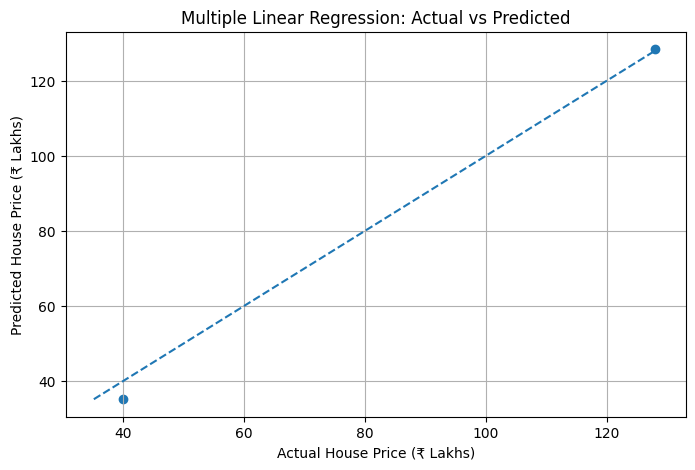

In [9]:
import matplotlib.pyplot as plt
 
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
 
# Perfect prediction reference line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())
plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")
 
plt.xlabel("Actual House Price (₹ Lakhs)")
plt.ylabel("Predicted House Price (₹ Lakhs)")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()